In [1]:
import numpy as np
import pandas as pd
import os

# ── Parameters ────────────────────────────────────────────────────────────────

param_names = ['beta1', 'beta2', 'delta1', 'delta2', 'gamma1', 'gamma2',
               'alpha1', 'alpha2', 'eta11', 'eta12', 'eta21', 'eta22']

theta_df = pd.DataFrame({
    'apr_may': np.load('../reports/parameters/theta_apr-may_SLSQP_power_2025-07-18.npy', allow_pickle=True).ravel(),
    'may_jun': np.load('../reports/parameters/theta_may-jun_power_oct25.npy', allow_pickle=True).ravel(),
    'jun_jul': np.load('../reports/parameters/theta_jun-jul_power_oct25.npy', allow_pickle=True).ravel()
}, index=param_names)

# ── Load 2017 data ─────────────────────────────────────────────────────────────

cost_df = pd.read_csv('../data/processed/cost_data.csv')

X = np.load('../data/processed/data_2017.npz')
N = int(X['N'])
field_ids = cost_df[(cost_df['Year'] == 2017) & (cost_df['Month'] == 'April')]['Field ID'].values

tI1 = X['tI1'].reshape(N,)  # R6 target indicator
tI2 = X['tI2'].reshape(N,)  # non-R6 target indicator

print(f"N total yards: {N}")
print(f"N R6 target yards (tI1): {int(tI1.sum())}")
print(f"N non-R6 target yards (tI2): {int(tI2.sum())}")

data = {
    'N'        : N,
    'field_ids': field_ids,
    'distance' : X['distance'],
    'wind_apr' : X['wind_apr'],  'wind_may': X['wind_may'],  'wind_jun': X['wind_jun'],
    'a_apr'    : X['a_apr'].reshape(N, 1), 'a_may': X['a_may'].reshape(N, 1), 'a_jun': X['a_jun'].reshape(N, 1),
    'y_apr'    : X['y_apr'].reshape(N, 1), 'y_may': X['y_may'].reshape(N, 1), 'y_jun': X['y_jun'].reshape(N, 1),
    'n_apr'    : X['n_apr'].reshape(N, 1), 'n_may': X['n_may'].reshape(N, 1), 'n_jun': X['n_jun'].reshape(N, 1),
    's_apr'    : X['s_apr'].reshape(N, 1), 's_may': X['s_may'].reshape(N, 1), 's_jun': X['s_jun'].reshape(N, 1),
    'sI1_apr'  : X['sI1_apr'].reshape(N, 1), 'sI1_may': X['sI1_may'].reshape(N, 1), 'sI1_jun': X['sI1_jun'].reshape(N, 1),
    'sI2'      : X['sI2'].reshape(N, 1),
    'tI1'      : tI1,
    'tI2'      : tI2,
}

# ── Coordinates lookup ─────────────────────────────────────────────────────────

coords = (cost_df[(cost_df['Year'] == 2017) & (cost_df['Month'] == 'April')]
          .set_index('Field ID')[['Centroid Lat', 'Centroid Long']])

# ── Period specifications ──────────────────────────────────────────────────────

periods = {
    'apr_may': {'a': 'a_apr', 'w': 'wind_apr', 'y': 'y_apr', 'n': 'n_apr', 's': 's_apr', 'sI1': 'sI1_apr'},
    'may_jun': {'a': 'a_may', 'w': 'wind_may', 'y': 'y_may', 'n': 'n_may', 's': 's_may', 'sI1': 'sI1_may'},
    'jun_jul': {'a': 'a_jun', 'w': 'wind_jun', 'y': 'y_jun', 'n': 'n_jun', 's': 's_jun', 'sI1': 'sI1_jun'},
}

N total yards: 122
N R6 target yards (tI1): 27
N non-R6 target yards (tI2): 95


In [2]:

# ── Compute and save networks ──────────────────────────────────────────────────

os.makedirs('../reports/networks/', exist_ok=True)

for period, keys in periods.items():

    gamma1 = theta_df.loc['gamma1', period]
    gamma2 = theta_df.loc['gamma2', period]
    alpha1 = theta_df.loc['alpha1', period]
    alpha2 = theta_df.loc['alpha2', period]
    eta21  = theta_df.loc['eta21', period]
    eta22  = theta_df.loc['eta22', period]

    a    = data[keys['a']]
    w    = data[keys['w']]
    y    = data[keys['y']]
    n    = data[keys['n']]
    s    = data[keys['s']]
    sI1  = data[keys['sI1']]
    sI2  = data['sI2']
    dist = data['distance']

    # Full N x N weight matrix
    weight = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            if i == j:
                continue

            # R6 target yards — only receive from yards with V6 initial strain (sI1)
            if tI1[i] == 1:
                weight[i, j] = (gamma1 *
                                (a[j, 0] * y[j, 0] / n[j, 0]) *
                                np.exp(-eta21 * s[j, 0]) *
                                w[j, i] *
                                (1 + dist[j, i])**(-alpha1) *
                                sI1[j, 0])

            # non-R6 target yards — receive from all sources (sI2 = 1)
            elif tI2[i] == 1:
                weight[i, j] = (gamma2 *
                                (a[j, 0] * y[j, 0] / n[j, 0]) *
                                np.exp(-eta22 * s[j, 0]) *
                                w[j, i] *
                                (1 + dist[j, i])**(-alpha2) *
                                sI2[j, 0])

    # Save N x N CSV: rows = targets (i), columns = sources (j)
    pd.DataFrame(weight,
                 index=field_ids,
                 columns=field_ids).to_csv(f'../reports/networks/network_{period}.csv', index_label='field_id')

    print(f"Saved network_{period}.csv ({N} x {N})")


# Add cultivar type indicator to coordinates
tI1 = X['tI1'].reshape(N,)
tI2 = X['tI2'].reshape(N,)

coords['cultivar_type'] = ['R6' if tI1[i] == 1 else 'non-R6' for i in range(N)]

# Save coordinates lookup
coords.to_csv('../reports/networks/field_coordinates.csv', index_label='field_id')
print("Saved field_coordinates.csv")

Saved network_apr_may.csv (122 x 122)
Saved network_may_jun.csv (122 x 122)
Saved network_jun_jul.csv (122 x 122)
Saved field_coordinates.csv


/var/folders/lt/4hpy5xm52tl3dl30dfm7545w0000gn/T/ipykernel_38405/3015388532.py:35: RuntimeWarning: divide by zero encountered in log10
  W_log = np.where(W > 0, np.log10(W), np.nan)


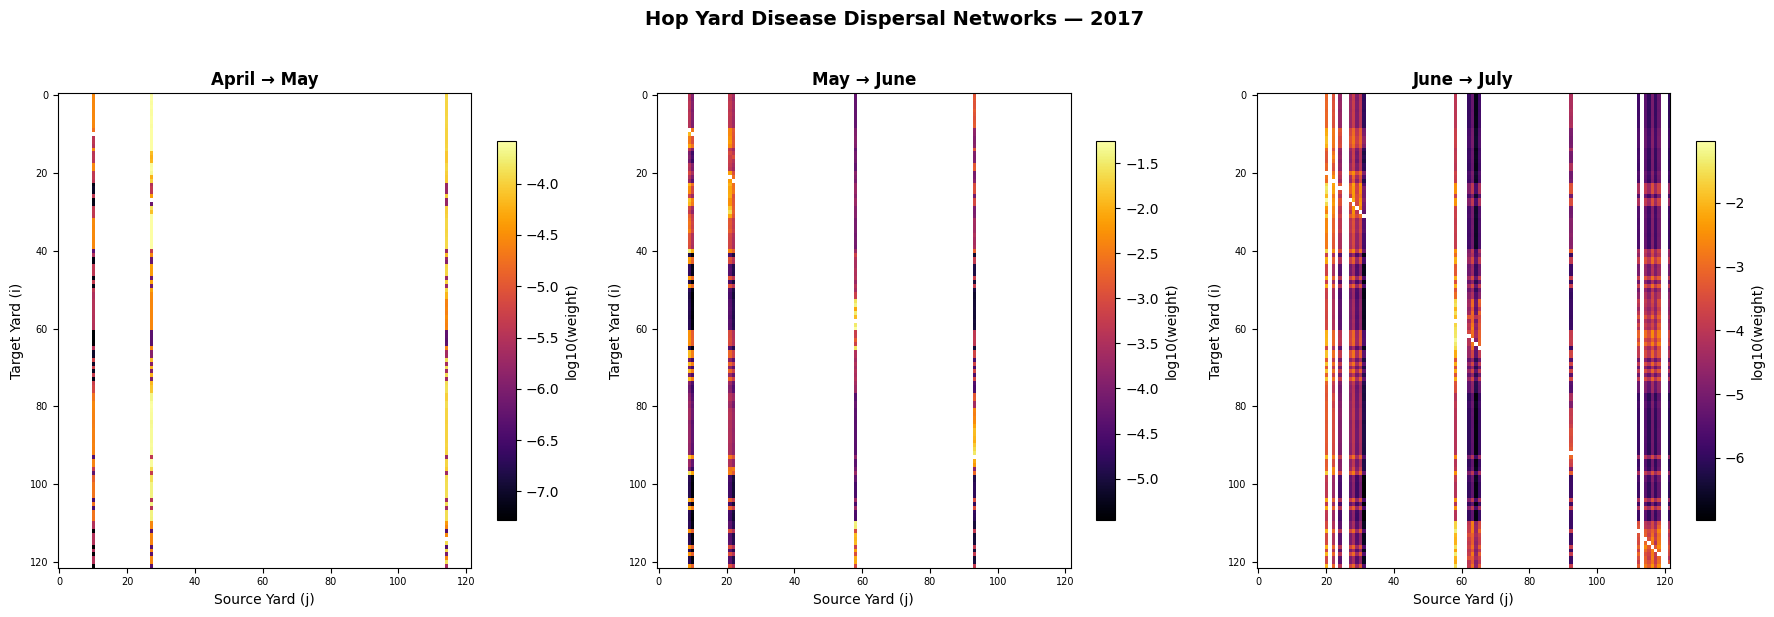

Saved map_apr_may.html
Saved map_may_jun.html
Saved map_jun_jul.html


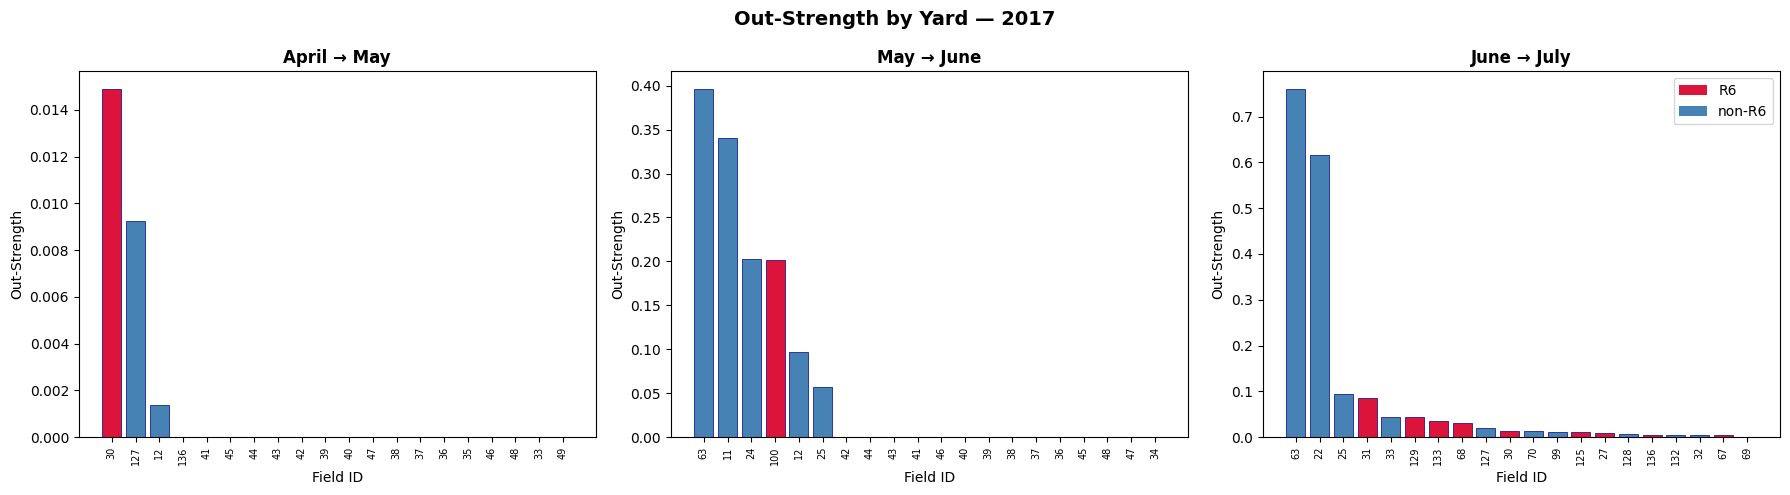

Done! Check ../reports/networks/ for output files.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
import networkx as nx

# ── Load networks and coordinates ─────────────────────────────────────────────

periods = ['apr_may', 'may_jun', 'jun_jul']
period_labels = {'apr_may': 'April → May', 'may_jun': 'May → June', 'jun_jul': 'June → July'}

networks = {p: pd.read_csv(f'../reports/networks/network_{p}.csv', index_col='field_id') for p in periods}
coords = pd.read_csv('../reports/networks/field_coordinates.csv', index_col='field_id')

# ── Load cultivar type indicators ─────────────────────────────────────────────

X = np.load('../data/processed/data_2017.npz')
N = int(X['N'])
field_ids = networks['apr_may'].index.values
tI1 = X['tI1'].reshape(N,)
tI2 = X['tI2'].reshape(N,)
cultivar_type = {fid: 'R6' if tI1[i] == 1 else 'non-R6' for i, fid in enumerate(field_ids)}

# ── Map center ────────────────────────────────────────────────────────────────

map_center = [coords['Centroid Lat'].mean(), coords['Centroid Long'].mean()]

# ── 1. HEATMAP OF WEIGHT MATRICES ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Hop Yard Disease Dispersal Networks — 2017', fontsize=14, fontweight='bold', y=1.02)

for ax, period in zip(axes, periods):
    W = networks[period].values
    W_log = np.where(W > 0, np.log10(W), np.nan)
    im = ax.imshow(W_log, cmap='inferno', aspect='auto')
    ax.set_title(period_labels[period], fontsize=12, fontweight='bold')
    ax.set_xlabel('Source Yard (j)', fontsize=10)
    ax.set_ylabel('Target Yard (i)', fontsize=10)
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, label='log10(weight)', shrink=0.8)

plt.tight_layout()
plt.savefig('../reports/networks/weight_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. SPATIAL NETWORK MAPS (one per period) ──────────────────────────────────

for period in periods:
    W = networks[period].values

    # Build directed graph
    G = nx.DiGraph()
    for fid in field_ids:
        G.add_node(fid,
                   lat=coords.loc[fid, 'Centroid Lat'],
                   lon=coords.loc[fid, 'Centroid Long'])

    for i, source in enumerate(field_ids):
        for j, target in enumerate(field_ids):
            if W[j, i] > 0:
                G.add_edge(source, target, weight=W[j, i])

    # Folium map
    m = folium.Map(location=map_center, zoom_start=10,
                   tiles='CartoDB positron')

    # Add legend
    legend_html = '''
    <div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
                background-color: white; padding: 10px; border-radius: 6px;
                border: 1px solid #ccc; font-size: 13px;">
        <b>Cultivar Type</b><br>
        <span style="color: crimson;">&#9679;</span> R6<br>
        <span style="color: steelblue;">&#9679;</span> non-R6
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    # Draw edges
    all_weights = [d['weight'] for _, _, d in G.edges(data=True)]
    if len(all_weights) > 0:
        max_weight = max(all_weights)

        for source, target, d in G.edges(data=True):
            src_lat = coords.loc[source, 'Centroid Lat']
            src_lon = coords.loc[source, 'Centroid Long']
            tgt_lat = coords.loc[target, 'Centroid Lat']
            tgt_lon = coords.loc[target, 'Centroid Long']
            weight_norm = d['weight'] / max_weight

            folium.PolyLine(
                locations=[[src_lat, src_lon], [tgt_lat, tgt_lon]],
                weight=max(0.5, weight_norm * 5),
                color='crimson',
                opacity=max(0.1, weight_norm * 0.8),
                tooltip=f"{source} → {target}: {d['weight']:.2e}"
            ).add_to(m)

    # Draw nodes colored by cultivar type
    for i, fid in enumerate(field_ids):
        lat = coords.loc[fid, 'Centroid Lat']
        lon = coords.loc[fid, 'Centroid Long']
        out_w = float(np.sum(W[:, i]))
        ctype = cultivar_type[fid]

        folium.CircleMarker(
            location=[lat, lon],
            radius=max(3, min(12, out_w / max(all_weights) * 15)) if len(all_weights) > 0 else 4,
            color='darkred' if ctype == 'R6' else 'darkblue',
            fill=True,
            fill_color='crimson' if ctype == 'R6' else 'steelblue',
            fill_opacity=0.7,
            tooltip=f"Field {fid} | {ctype} | Out-strength: {out_w:.2e}"
        ).add_to(m)

    m.save(f'../reports/networks/map_{period}.html')
    print(f"Saved map_{period}.html")

# ── 3. OUT-STRENGTH COMPARISON ACROSS PERIODS ─────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Out-Strength by Yard — 2017', fontsize=14, fontweight='bold')

for ax, period in zip(axes, periods):
    W = networks[period].values

    out_strength = W.sum(axis=0)
    sorted_idx = np.argsort(out_strength)[::-1]
    top_n = 20

    colors = ['crimson' if cultivar_type[field_ids[sorted_idx[k]]] == 'R6' 
              else 'steelblue' for k in range(top_n)]

    ax.bar(range(top_n), out_strength[sorted_idx[:top_n]], color=colors, edgecolor='navy', linewidth=0.5)
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(field_ids[sorted_idx[:top_n]], rotation=90, fontsize=7)
    ax.set_title(period_labels[period], fontsize=12, fontweight='bold')
    ax.set_xlabel('Field ID', fontsize=10)
    ax.set_ylabel('Out-Strength', fontsize=10)

# Add legend to last plot
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='crimson', label='R6'),
                   Patch(facecolor='steelblue', label='non-R6')]
axes[-1].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('../reports/networks/out_strength.png', dpi=150, bbox_inches='tight')
plt.show()

print("Done! Check ../reports/networks/ for output files.")